# 06 — Model & Session Analysis

Full comprehension report for each HAR iteration:

| Layer | What we measure |
|-------|------------------|
| **Training set** | precision, recall, F1, confusion matrix (holdout split) |
| **Live / eval logs** | confidence, latency, label distribution from `har_sessions/` |
| **Cross-run** | compare model tags over time via `index.csv` |

Outputs → `outputs/har_analysis/YYYY-MM-DD_<model_tag>/`

## 1 — Configuration

In [8]:
import sys
from pathlib import Path

NB = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NB))

from IPython.display import Image, Markdown, display
import pandas as pd

from lib.har_analysis import (
    ANALYSIS_DIR,
    eval_checkpoint_on_embeddings,
    load_all_events,
    load_sessions_index,
    run_full_analysis,
)
from lib.paths import CHECKPOINTS_DIR, OUTPUTS_DIR, SESSIONS_DIR
from lib.session_log import model_tag_from_checkpoint

CHECKPOINT = CHECKPOINTS_DIR / "har_vjepa_all14_100each.pt"  # change per iteration
MODEL_TAG = model_tag_from_checkpoint(CHECKPOINT)

print("Checkpoint:", CHECKPOINT.name)
print("Model tag:", MODEL_TAG)
print("Sessions index:", SESSIONS_DIR / "index.csv")
print("Embeddings:", OUTPUTS_DIR / "embeddings.npz")

Checkpoint: har_vjepa_all14_100each.pt
Model tag: all14_100each
Sessions index: /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/notebooks/outputs/har_sessions/index.csv
Embeddings: /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/notebooks/outputs/embeddings.npz


## 2 — Run full analysis (charts + REPORT.md)

In [9]:
if not CHECKPOINT.is_file():
    raise FileNotFoundError("Train first (03 or 00 pipeline)")

result = run_full_analysis(CHECKPOINT)
OUT = Path(result["out_dir"])
summary = result["summary"]

print(f"Saved → {OUT}")
print(f"Accuracy (holdout): {summary['accuracy']:.1%}")
print(f"Macro F1:          {summary['macro_f1']:.3f}")
print(f"Weighted F1:       {summary['weighted_f1']:.3f}")
print(f"Sessions logged:   {summary['n_sessions']}")
print(f"Live events:       {summary['n_live_events']}")

display(Markdown((OUT / "REPORT.md").read_text()))

Saved → /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/notebooks/outputs/har_analysis/2026-06-07_all14_100each
Accuracy (holdout): 32.0%
Macro F1:          0.285
Weighted F1:       0.298
Sessions logged:   2
Live events:       46


# HAR Model Analysis — `all14_100each`

Generated: 2026-06-07T17:03:50

## Model identity

| Field | Value |
|-------|-------|
| Checkpoint | `har_vjepa_all14_100each.pt` |
| Embedding | `facebook/vjepa2-vitl-fpc64-256` |
| Classes | 14 |
| Train clips | 1012 |
| Holdout clips | 253 |

## Holdout metrics (training set)

| Metric | Value |
|--------|-------|
| Accuracy | **32.0%** |
| Macro F1 | **0.285** |
| Weighted F1 | **0.298** |
| Macro precision | 0.311 |
| Macro recall | 0.304 |

## Live / eval sessions

- Sessions logged: **2**
- Total inferences: **46**
- Confirmed detections: **16**
- Mean confidence: **36.6%**
- Mean infer latency: **1803 ms**

## Charts

- `class_balance`: 01_train_class_balance.png
- `confusion_matrix`: 02_confusion_matrix.png
- `per_class_metrics`: 03_per_class_prf1.png
- `session_confidence`: 05_session_confidence.png
- `session_labels`: 06_session_label_distribution.png
- `model_comparison`: 07_model_comparison.png
- `inference_latency`: 08_inference_latency.png


In [10]:
import json
from lib.constants import BLOCKED_ACTIONS
from lib.har_train import train_from_npz
import numpy as np

cmp_path = OUTPUTS_DIR / "har_analysis" / "compare_14vs12_holdout.json"
npz12 = OUTPUTS_DIR / "embeddings_train12.npz"
ckpt12 = CHECKPOINTS_DIR / "har_vjepa_train12_100each.pt"

if cmp_path.is_file():
    display(pd.DataFrame([json.loads(cmp_path.read_text())]).T)
else:
    data = np.load(OUTPUTS_DIR / "embeddings.npz", allow_pickle=True)
    X, y = data["X"], data["y"]
    class_names = list(data["class_names"])
    blocked = {b.casefold() for b in BLOCKED_ACTIONS}
    keep = [n for n in class_names if n.casefold() not in blocked]
    idx_map = {n: i for i, n in enumerate(keep)}
    mask = np.array([class_names[int(yi)].casefold() not in blocked for yi in y])
    np.savez(npz12, X=X[mask], y=np.array([idx_map[class_names[int(yi)]] for yi in y[mask]]), class_names=np.array(keep, dtype=object))
    train_from_npz(npz12, ckpt12, exclude_labels=list(BLOCKED_ACTIONS), epochs=25)
    r14 = eval_checkpoint_on_embeddings(CHECKPOINT)
    r12 = eval_checkpoint_on_embeddings(ckpt12, npz_path=npz12)
    cmp = {"all14": r14["accuracy"], "train12": r12["accuracy"], "delta": r12["accuracy"] - r14["accuracy"]}
    print(cmp)

,0
all14_100each,"{'n_samples': 1265, 'n_classes': 14, 'accuracy..."
train12_100each,"{'n_samples': 1065, 'n_classes': 12, 'accuracy..."
delta_accuracy,0.046
delta_macro_f1,0.0403


## 3 — Per-class metrics (training holdout)

,class,precision,recall,f1,support
5,Put down component,50.00%,85.00%,62.96%,20.000000
4,Picking left,46.15%,60.00%,52.17%,20.000000
0,Assemble system,44.00%,55.00%,48.89%,20.000000
13,Turn sheets,34.48%,50.00%,40.82%,20.000000
8,Put down subsystem,37.50%,40.00%,38.71%,15.000000
1,Consult sheets,75.00%,15.00%,25.00%,20.000000
10,Take measuring rod,33.33%,20.00%,25.00%,15.000000
6,Put down measuring rod,30.00%,20.00%,24.00%,15.000000
3,Picking in front,20.00%,25.00%,22.22%,20.000000
9,Take component,23.08%,15.00%,18.18%,20.000000


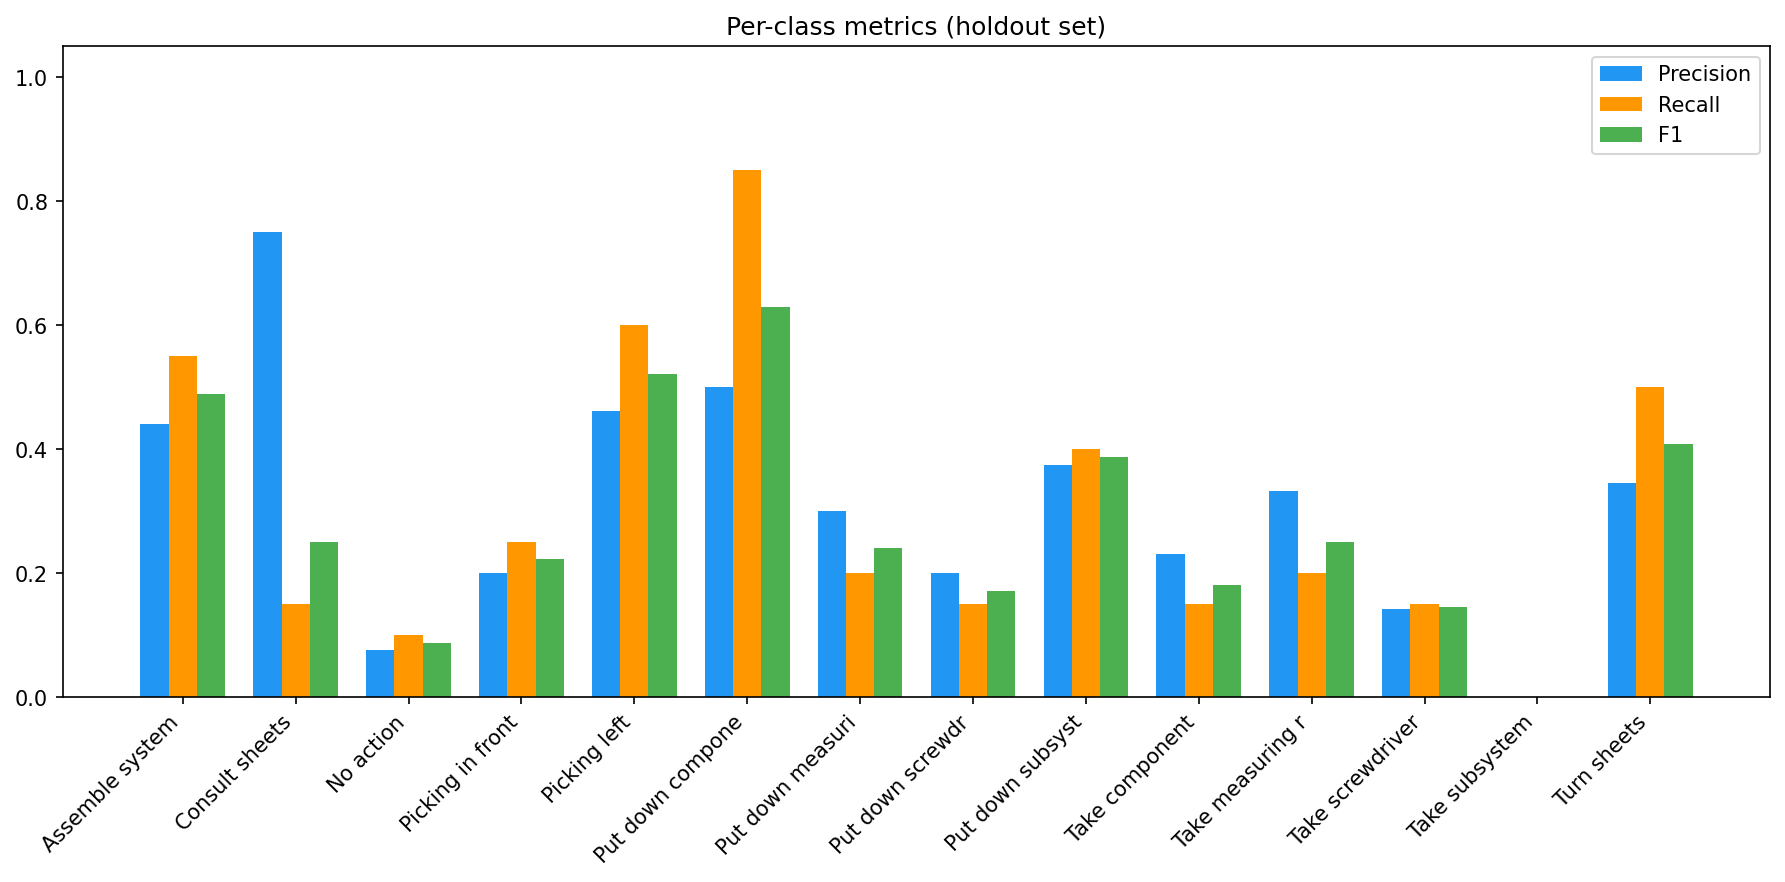

In [11]:
metrics = result["metrics_df"].sort_values("f1", ascending=False)
display(metrics.style.format({"precision": "{:.2%}", "recall": "{:.2%}", "f1": "{:.2%}"}))

display(Image(filename=str(OUT / "03_per_class_prf1.png"), width=900))

## 4 — Confusion matrix & training balance

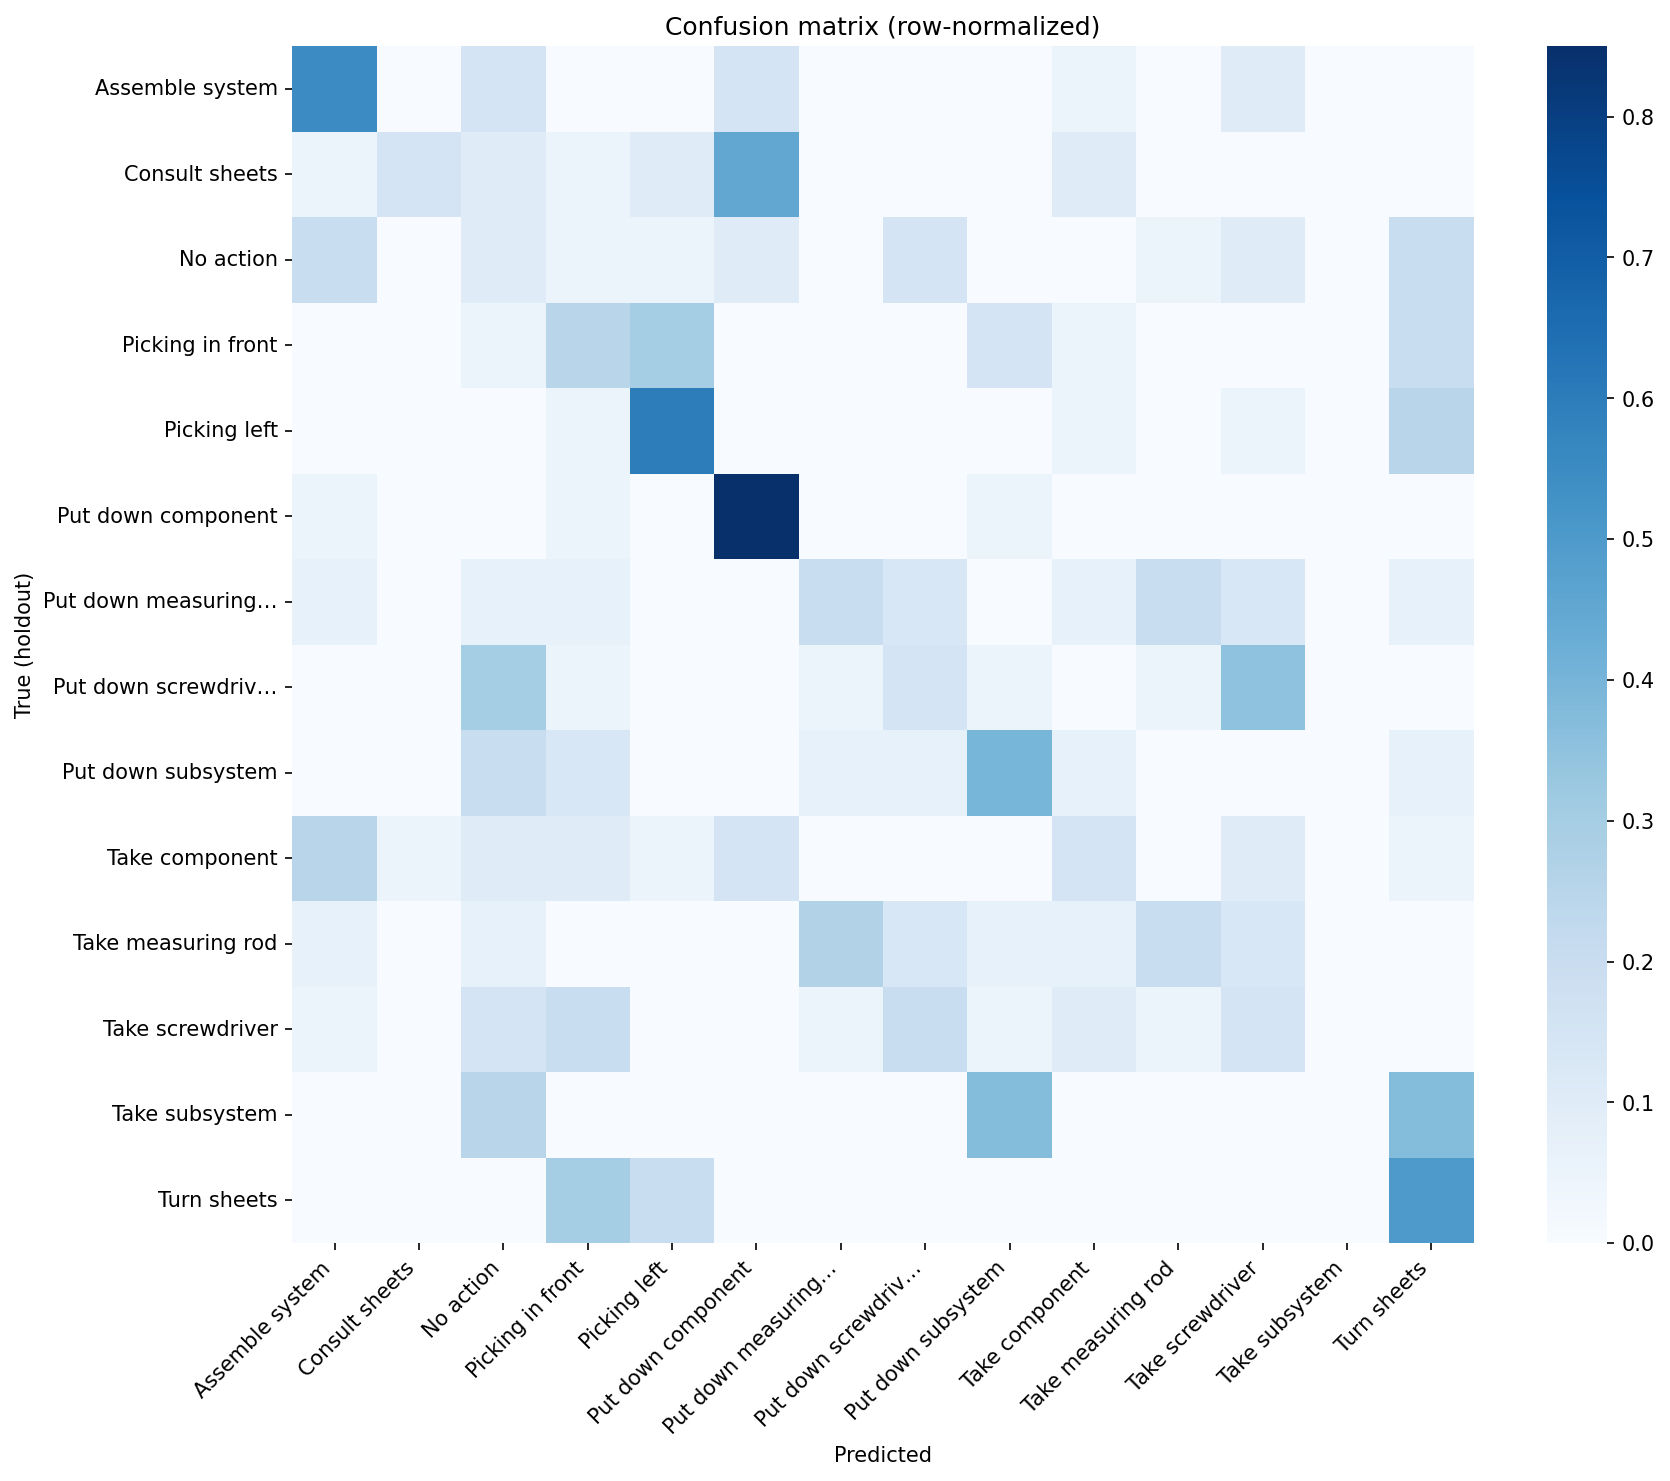

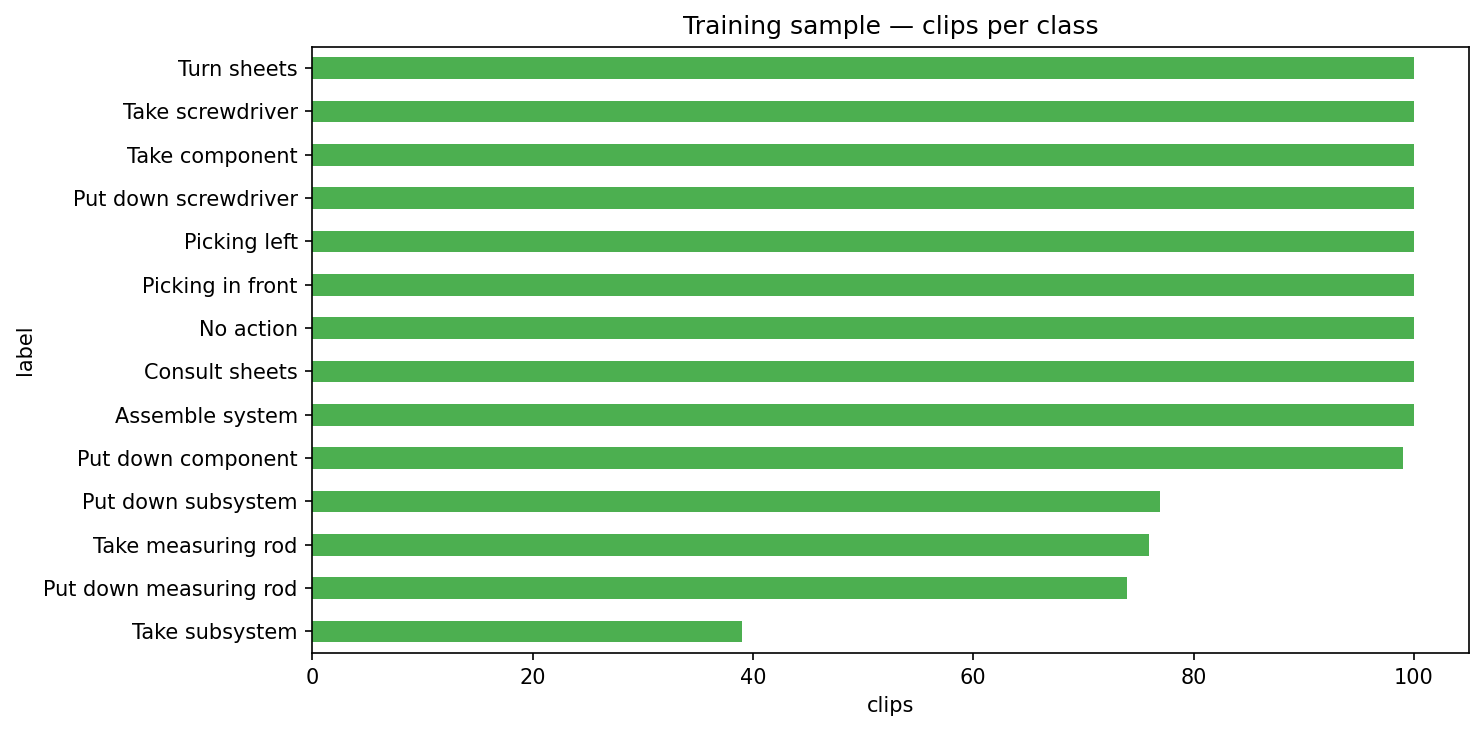

In [12]:
display(Image(filename=str(OUT / "02_confusion_matrix.png"), width=700))
display(Image(filename=str(OUT / "01_train_class_balance.png"), width=700))
if (OUT / "04_training_loss.png").is_file():
    display(Image(filename=str(OUT / "04_training_loss.png"), width=600))

## 5 — Live / eval session logs (`har_sessions/`)

,run_id,date,model_tag,checkpoint,embedding_model,classifier_version,source,video,started_at,ended_at,n_events,n_confirmed,n_persons,session_dir
0,har-600026e426fa,2026-06-07,all14_5each,har_vjepa_all14_5each.pt,facebook/vjepa2-vitl-fpc64-256,all14_5each,eval,Industrial-One.mp4,2026-06-07T21:25:20.585018+00:00,2026-06-07T21:25:30.700809+00:00,0,0,0,2026-06-07/har-600026e426fa_all14_5each
1,har-271a703b5e61,2026-06-07,all14_5each,har_vjepa_all14_5each.pt,facebook/vjepa2-vitl-fpc64-256,all14_5each,eval,Industrial-One.mp4,2026-06-07T21:25:37.056865+00:00,2026-06-07T21:25:47.562325+00:00,0,0,0,2026-06-07/har-271a703b5e61_all14_5each
2,har-9b28c2b8a3e3,2026-06-07,all14_5each,har_vjepa_all14_5each.pt,facebook/vjepa2-vitl-fpc64-256,all14_5each,eval,Industrial-One.mp4,2026-06-07T21:26:10.912552+00:00,2026-06-07T21:26:44.171013+00:00,13,6,6,2026-06-07/har-9b28c2b8a3e3_all14_5each
3,har-10c27ea16be9,2026-06-07,all14_5each,har_vjepa_all14_5each.pt,facebook/vjepa2-vitl-fpc64-256,all14_5each,eval,Industrial-One.mp4,2026-06-07T21:29:53.018567+00:00,2026-06-07T21:30:37.268949+00:00,23,7,6,2026-06-07/har-10c27ea16be9_all14_5each
4,har-7e98f4904156,2026-06-07,all14_5each,har_vjepa_all14_5each.pt,facebook/vjepa2-vitl-fpc64-256,all14_5each,live,Industrial-One.mp4,2026-06-07T21:30:37.543648+00:00,2026-06-07T21:32:31.718718+00:00,57,25,8,2026-06-07/har-7e98f4904156_all14_5each
5,har-a1a5f4125b2a,2026-06-07,all14_100each,har_vjepa_all14_100each.pt,facebook/vjepa2-vitl-fpc64-256,all14_100each,eval,Industrial-One.mp4,2026-06-07T22:53:52.791551+00:00,2026-06-07T22:54:35.785985+00:00,23,8,6,2026-06-07/har-a1a5f4125b2a_all14_100each
6,har-e24c5d30b9ed,2026-06-07,all14_100each,har_vjepa_all14_100each.pt,facebook/vjepa2-vitl-fpc64-256,all14_100each,eval,Industrial-One.mp4,2026-06-07T23:02:43.283053+00:00,2026-06-07T23:03:35.146358+00:00,23,8,6,2026-06-07/har-e24c5d30b9ed_all14_100each



46 inference events for model `all14_100each`


,session_id,track_id,frame_idx,action_label,confidence,confirmed_detection,infer_ms
0,har-a1a5f4125b2a,1,16,Assemble system,0.3253,True,1647.53
1,har-a1a5f4125b2a,2,16,Put down component,0.4629,True,1571.34
2,har-a1a5f4125b2a,1,32,Assemble system,0.3072,False,1633.33
3,har-a1a5f4125b2a,2,32,Assemble system,0.3810,False,1642.19
4,har-a1a5f4125b2a,18,32,Assemble system,0.3824,True,1660.63
5,har-a1a5f4125b2a,2,48,Assemble system,0.3686,True,1700.18
6,har-a1a5f4125b2a,18,48,Assemble system,0.4141,False,1585.44
7,har-a1a5f4125b2a,19,48,Assemble system,0.3743,True,1590.24
8,har-a1a5f4125b2a,26,48,Put down component,0.3968,True,1592.17
9,har-a1a5f4125b2a,2,64,Put down component,0.3985,False,1580.44


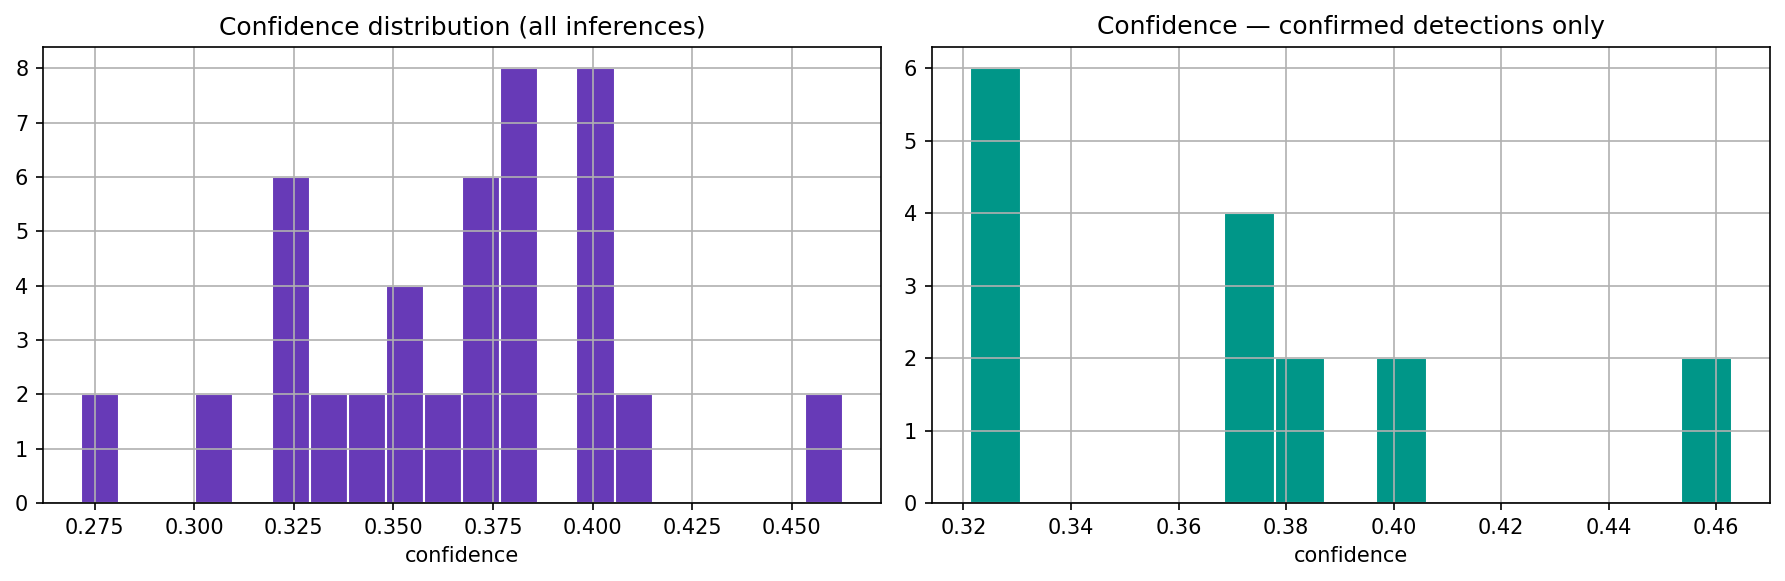

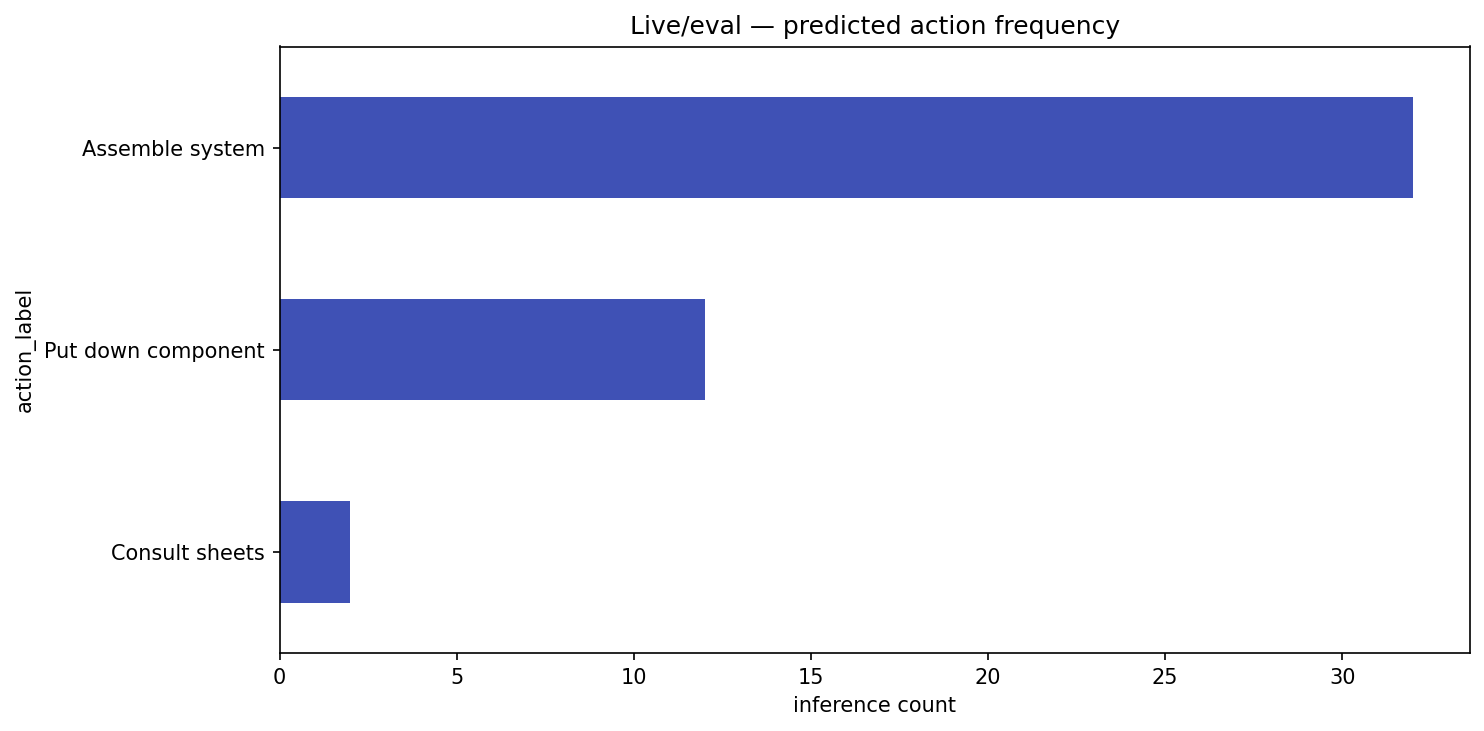

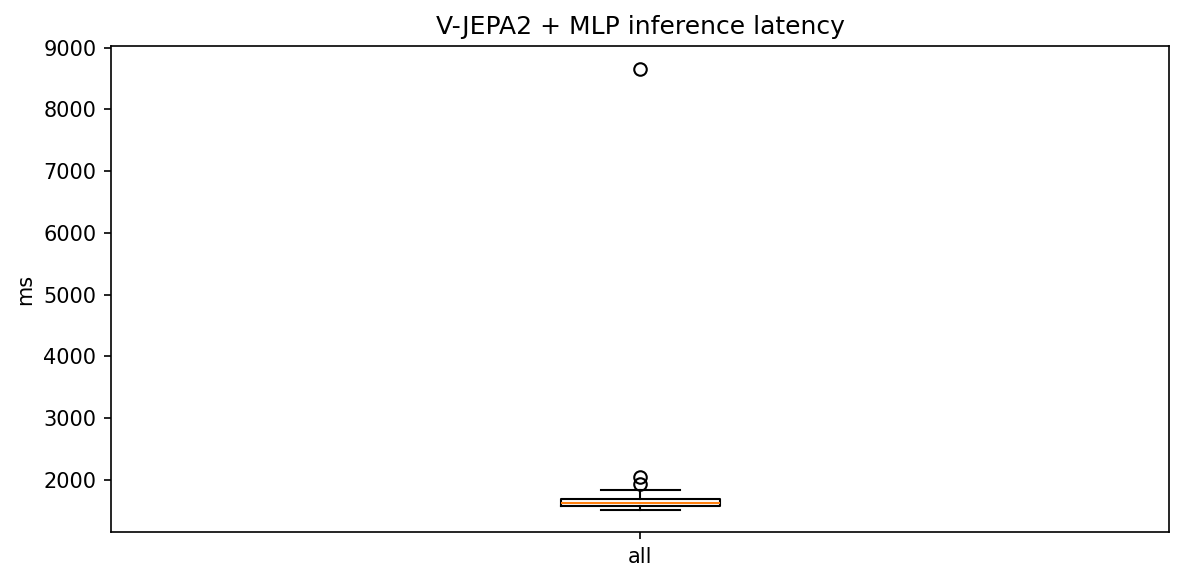

In [13]:
index_df = load_sessions_index()
if index_df.empty:
    print("No sessions yet — run 04 eval or 05 live first.")
else:
    display(index_df)

events = result["events"]
if not events.empty:
    print(f"\n{len(events)} inference events for model `{MODEL_TAG}`")
    cols = ["session_id", "track_id", "frame_idx", "action_label", "confidence", "confirmed_detection", "infer_ms"]
    display(events[cols].head(20))
    display(Image(filename=str(OUT / "05_session_confidence.png"), width=800))
    display(Image(filename=str(OUT / "06_session_label_distribution.png"), width=700))
    if (OUT / "08_inference_latency.png").is_file():
        display(Image(filename=str(OUT / "08_inference_latency.png"), width=500))

## 6 — Compare model iterations

,model_tag,sessions,events,confirmed
0,all14_100each,2,46,16
1,all14_5each,5,93,38


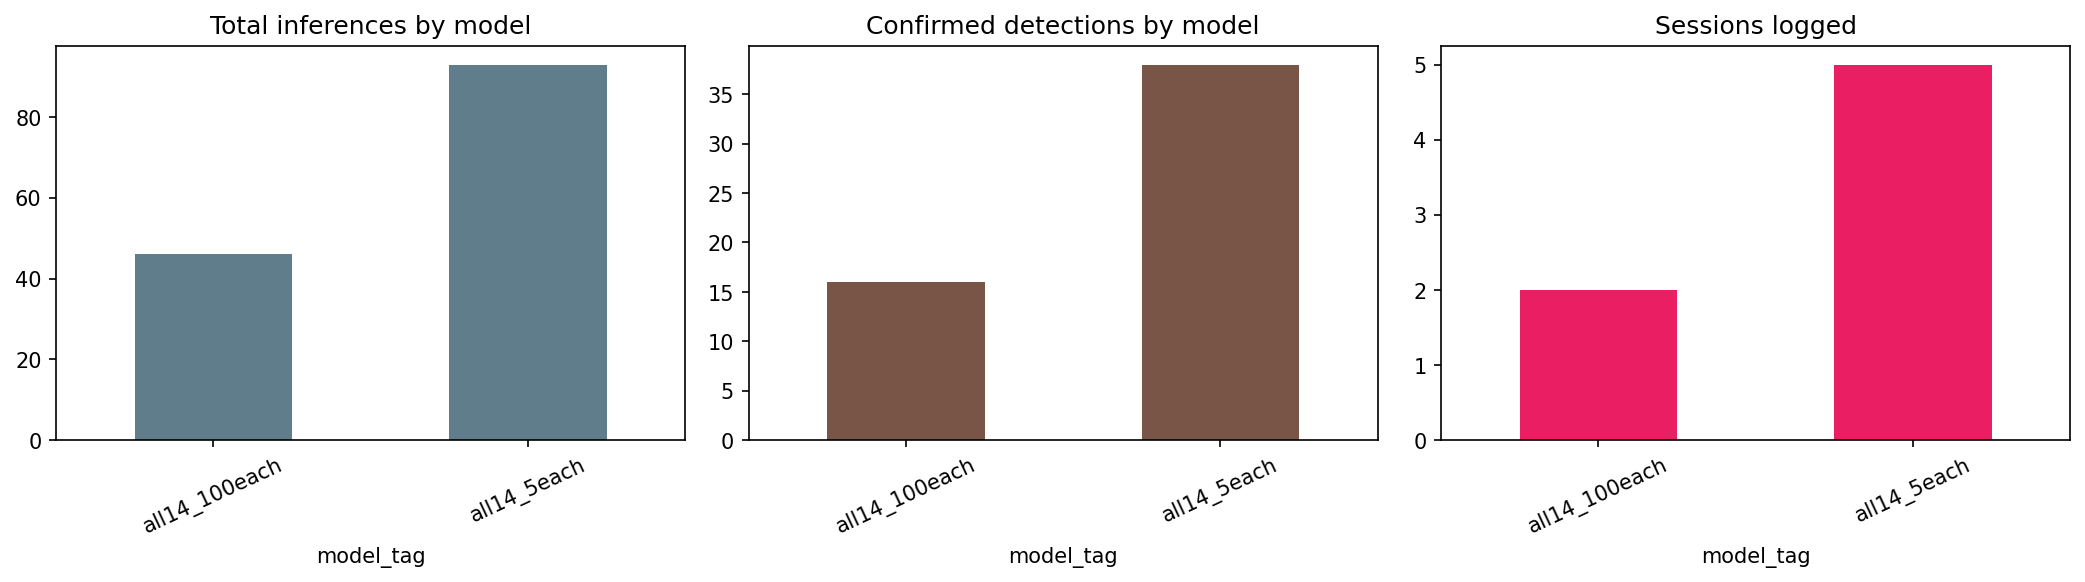

In [14]:
if not index_df.empty and index_df["model_tag"].nunique() >= 1:
    cmp = index_df.groupby("model_tag", as_index=False).agg(
        sessions=("run_id", "count"),
        events=("n_events", "sum"),
        confirmed=("n_confirmed", "sum"),
    )
    display(cmp)
    if (OUT / "07_model_comparison.png").is_file():
        display(Image(filename=str(OUT / "07_model_comparison.png"), width=900))
else:
    print("Log more runs (different checkpoint names) to compare iterations.")

## 7 — Detection frame gallery (confirmed)

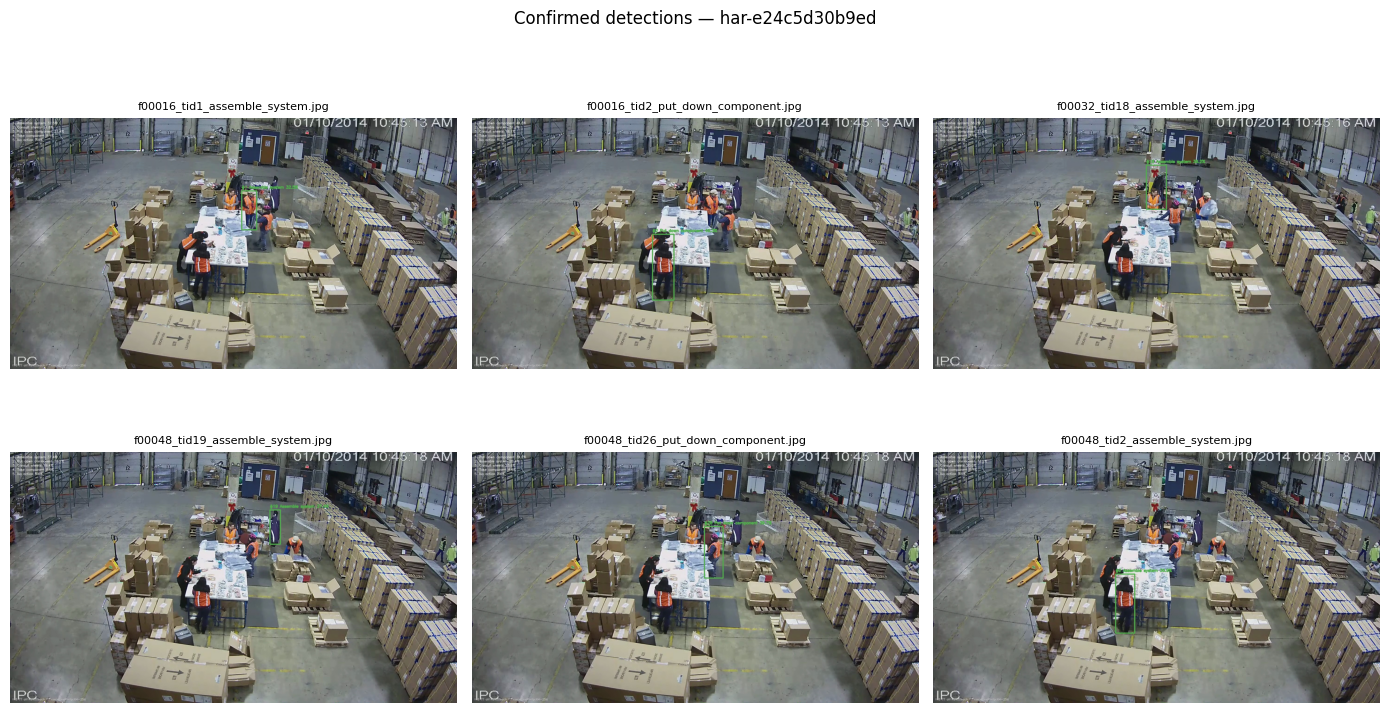

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if index_df.empty:
    print("No sessions.")
else:
    latest = index_df[index_df["model_tag"] == MODEL_TAG].iloc[-1]
    session_dir = SESSIONS_DIR / latest["session_dir"]
    frames_dir = session_dir / "frames"
    jpgs = sorted(frames_dir.glob("f*.jpg"))[:6] if frames_dir.is_dir() else []
    if not jpgs:
        print(f"No confirmed frame snapshots in {frames_dir}")
    else:
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        for ax, p in zip(axes.flat, jpgs):
            ax.imshow(mpimg.imread(p))
            ax.set_title(p.name[:40], fontsize=8)
            ax.axis("off")
        plt.suptitle(f"Confirmed detections — {latest['run_id']}")
        plt.tight_layout()
        plt.show()